In [ ]:
!mkdir -p /content/vncorenlp/models/wordsegmenter

In [ ]:
!wget -q https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab \
    -O /content/vncorenlp/models/wordsegmenter/vi-vocab

!wget -q https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr \
    -O /content/vncorenlp/models/wordsegmenter/wordsegmenter.rdr


In [ ]:
!cp -r "/content/vncorenlp/models" "/content/drive/MyDrive/Python /Sentiment Analysis/VnCoreNLP/"

In [4]:
%cd "/content/drive/MyDrive/Python /Sentiment Analysis"

/content/drive/MyDrive/Python /Sentiment Analysis


In [ ]:
%%writefile requirements.txt
torch
transformers
streamlit
pandas
numpy
scikit-learn
matplotlib
openpyxl
google-play-scraper
vncorenlp

Overwriting requirements.txt


In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 48.4 MB/s eta 0:00:00
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2646044 sha256=a9a2de2381294a64a6dd3d42f1f29703a877e3a7b6b3d1162ff2c2133ca0c460
  Stored in directory: /root/.cache/pip/wheels/51/26/b6/2e6fe7824cea04f98643746a6c8c8763e14790fa70391ca97f
Successfully built vncorenlp


In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-11-jdk

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-common at-spi2-core fonts-dejavu-core fonts-dejavu-extra
  fonts-dejavu-mono gsettings-desktop-schemas libatk-bridge2.0-0t64
  libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0t64 libatspi2.0-0t64
  libxcomposite1 libxt-dev libxtst6 libxxf86dga1 openjdk-11-jdk-headless
  openjdk-11-jre openjdk-11-jre-headless session-migration x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm libnss-mdns
  fonts

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get update

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:5 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Reading package lists... Done
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repo

In [6]:
%cd /content/drive/MyDrive/Python /Sentiment Analysis

/content/drive/MyDrive/Python /Sentiment Analysis


In [1]:
%%writefile preprocess.py

import pandas as pd
from google_play_scraper import Sort, reviews
from vncorenlp import VnCoreNLP

# Khởi tạo công cụ tách từ tiếng Việt
print("Đang khởi tạo VnCoreNLP...")
rdrsegmenter = VnCoreNLP("/content/drive/MyDrive/Python /Sentiment Analysis/VnCoreNLP/VnCoreNLP-1.1.1.jar", annotators="wseg", max_heap_size="-Xmx512m")
print("Đã khởi tạo VnCoreNLP.")
speacial_chars = {
    ":)": " tích_cực ",
    ":D": " vui_vẻ ",
    ":>": " hạnh_phúc ",
    "^^": " cười_tươi ",
    ":- )": " tích_cực ",
    "(:": " tích_cực ",

    ":(": " tiêu_cực ",
    ":<": " buồn_bã ",
    ":'(": " khóc ",
    "😭": " khóc ",
    ":p": " trêu_chọc ",
    ":P": " trêu_chọc ",
    ":o": " ngạc_nhiên ",
    ":O": " ngạc_nhiên ",
    "-_-": " khó_chịu ",
    ":-|": " nghiêm_túc "
}
def preprocess_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    for char, replacement in speacial_chars.items(): text = text.replace(char, replacement)
    try:
        sentences = rdrsegmenter.tokenize(text)
        flat_text = " ".join([" ".join(sentence) for sentence in sentences])
        return flat_text
    except Exception as e:
        print(e)
        return text

def run_pipeline(app_id="com.shopee.vn", count=30000):
    print("Đang cào dữ liệu từ Google Play...")
    raw_data, _ = reviews(
        app_id,
        lang='vi',
        country='vn',
        sort=Sort.NEWEST,
        count=count,
        filter_score_with=None
    )
    print("Đã cào dữ liệu xong.")

    df = pd.DataFrame(raw_data)[['content', 'score']]
    df.rename(columns={'content':'text', 'score':'rating'}, inplace=True)
    print("Đang tiền xử lý dữ liệu...")
    df = df[df['rating']!=3]
    df['label'] = df['rating'].apply(lambda x: 1 if x>3 else 0)

    clean_df = df[['text', 'label']].drop_duplicates(subset=['text']).dropna()
    print("Đang chạy tách từ bằng VnCoreNLP...")
    clean_df['text'] = clean_df['text'].apply(preprocess_vietnamese_text)
    print("Đã tách từ xong.")
    clean_df.to_csv("clean_dataset.csv", index=False, encoding="utf-8-sig")
    print("Data set đã được làm sạch. Đã sẵn sàng để huấn luyện mô hình!")

if __name__ == "__main__":
    run_pipeline()


Writing preprocess.py


In [ ]:
%%writefile models.py
import torch
import torch.nn as nn
from transformers import AutoModel

class PhoBERT_BILSTM_Attention(nn.Module):
    def __init__(self, hidden_dim=128, num_classes=2):
        super().__init__()
        # Tải mô hình PhoBERT pre-trained
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")

        # Đóng băng (freeze) toàn bộ trọng số của PhoBERT pre-trained
        for param in self.phobert.parameters():
            param.requires_grad = False

        # Mở khóa đóng băng 2 tầng Encoder cuối cùng (tầng 10 & 11) + tầng Pooler
        for name, param in self.phobert.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
                param.requires_grad = True

        self.bilstm = nn.LSTM(768, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)

        embeddings = outputs.last_hidden_state
        lstm_out, _ = self.bilstm(embeddings)

        # Tính toán xem từ nào trong câu quan trọng nhất bằng attention
        attn_logits = self.attention(lstm_out)  # Tính điểm số quan trọng thô cho từng từ

        attn_logits = attn_logits.squeeze(-1).masked_fill( attention_mask == 0,-1e9)  # Xử lý attention masking

        attn_weights = torch.softmax( attn_logits, dim=1)  # Chuẩn hóa attention score giữa các token; tổng trọng số = 1

        attn_weights = attn_weights.unsqueeze(-1)  # [batch, seq_len] -> [batch, seq_len, 1]

        context = torch.sum(lstm_out * attn_weights, dim=1)  # Tạo vector biểu diễn bằng tổng có trọng số của các hidden state
        logits = self.fc(context)
        return logits, attn_weights

Overwriting models.py


In [ ]:
%%writefile train.py
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from models import PhoBERT_BILSTM_Attention

# ============================================================
# CẤU HÌNH
# ============================================================
SEED = 42
BATCH_SIZE = 8
MAX_LEN = 64
LEARNING_RATE = 2e-5
EPOCHS = 5

# Tỷ lệ dữ liệu: Train 70% - Dev 15% - Test 15%
TRAIN_RATIO = 0.70
DEV_RATIO = 0.15
TEST_RATIO = 0.15

# Đảm bảo kết quả chia dữ liệu có thể tái lập

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        inputs = tokenizer(
            str(self.texts[item]),
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": inputs["input_ids"].flatten(),
            "attention_mask": inputs["attention_mask"].flatten(),
            "label": torch.tensor(self.labels[item], dtype=torch.long)
        }


def evaluate(model, loader, device):
    """Đánh giá mô hình trên một tập dữ liệu."""
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, _ = model(input_ids, mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }


def train():
    # 1. Đọc dữ liệu đã tiền xử lý
    df = pd.read_csv("clean_dataset.csv").dropna(subset=["text", "label"])
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

    # Chuẩn hóa kiểu nhãn
    df["label"] = df["label"].astype(int)

    # 2. Chia Train 70% - Dev 15% - Test 15%
    #    Chia 2 bước và stratify theo label để giữ tỷ lệ lớp.
    train_df, temp_df = train_test_split(
        df,
        test_size=(DEV_RATIO + TEST_RATIO),
        random_state=SEED,
        stratify=df["label"]
    )

    dev_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (DEV_RATIO + TEST_RATIO),
        random_state=SEED,
        stratify=temp_df["label"]
    )

    # Kiểm tra tỷ lệ thực tế
    total = len(df)
    print("=" * 60)
    print("PHÂN CHIA DỮ LIỆU: TRAIN 70% - DEV 15% - TEST 15%")
    print("=" * 60)
    print(f"Tổng số mẫu : {total}")
    print(f"Train       : {len(train_df)} ({len(train_df)/total:.2%})")
    print(f"Dev         : {len(dev_df)} ({len(dev_df)/total:.2%})")
    print(f"Test        : {len(test_df)} ({len(test_df)/total:.2%})")

    print("\nPhân bố nhãn:")
    for name, part in [("Train", train_df), ("Dev", dev_df), ("Test", test_df)]:
        counts = part["label"].value_counts().sort_index().to_dict()
        print(f"{name}: {counts}")

    # Lưu các tập dữ liệu để có thể kiểm tra/tái lập thực nghiệm
    train_df.to_csv("train_dataset.csv", index=False, encoding="utf-8-sig")
    dev_df.to_csv("dev_dataset.csv", index=False, encoding="utf-8-sig")
    test_df.to_csv("test_dataset.csv", index=False, encoding="utf-8-sig")

    # 3. DataLoader
    train_loader = DataLoader(
        SentimentDataset(train_df["text"], train_df["label"]),
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    dev_loader = DataLoader(
        SentimentDataset(dev_df["text"], dev_df["label"]),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    test_loader = DataLoader(
        SentimentDataset(test_df["text"], test_df["label"]),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # 4. Khởi tạo mô hình
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\nDevice:", device)
    print("Train batches:", len(train_loader))
    print("Dev batches:", len(dev_loader))
    print("Test batches:", len(test_loader))

    model = PhoBERT_BILSTM_Attention().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    # 5. Huấn luyện: chỉ dùng Dev để chọn best_model.pt
    best_dev_acc = -1.0
    history = []

    print("\nĐang bắt đầu huấn luyện mô hình...")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, _ = model(input_ids, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        dev_result = evaluate(model, dev_loader, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "dev_loss": dev_result["loss"],
            "dev_accuracy": dev_result["accuracy"],
            "dev_precision": dev_result["precision"],
            "dev_recall": dev_result["recall"],
            "dev_f1": dev_result["f1"]
        })

        print(
            f"Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss:.4f} - "
            f"Dev Loss: {dev_result['loss']:.4f} - "
            f"Dev Acc: {dev_result['accuracy']:.4f} - "
            f"Dev F1: {dev_result['f1']:.4f}"
        )

        # Chỉ dùng DEV để chọn checkpoint tốt nhất.
        if dev_result["accuracy"] > best_dev_acc:
            best_dev_acc = dev_result["accuracy"]
            torch.save(model.state_dict(), "best_model.pt")
            print("💾 Đã lưu best_model.pt theo Dev Accuracy!")

    # Lưu lịch sử huấn luyện
    pd.DataFrame(history).to_csv(
        "training_history.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # 6. Đánh giá TEST sau khi đã chọn best_model.pt
    print("\n" + "=" * 60)
    print("ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST")
    print("=" * 60)

    model.load_state_dict(
        torch.load("best_model.pt", map_location=device)
    )

    test_result = evaluate(model, test_loader, device)

    print(f"Test Loss      : {test_result['loss']:.4f}")
    print(f"Test Accuracy  : {test_result['accuracy']:.4f}")
    print(f"Test Precision : {test_result['precision']:.4f}")
    print(f"Test Recall    : {test_result['recall']:.4f}")
    print(f"Test F1-score  : {test_result['f1']:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            test_result["y_true"],
            test_result["y_pred"],
            target_names=["Tiêu cực", "Tích cực"],
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        test_result["y_true"],
        test_result["y_pred"]
    )
    cm_df = pd.DataFrame(
        cm,
        index=["Thực tế: Tiêu cực", "Thực tế: Tích cực"],
        columns=["Dự đoán: Tiêu cực", "Dự đoán: Tích cực"]
    )
    print("Confusion Matrix:")
    print(cm_df)

    # Lưu kết quả test để đưa vào báo cáo
    test_metrics = pd.DataFrame([{
        "test_loss": test_result["loss"],
        "test_accuracy": test_result["accuracy"],
        "test_precision": test_result["precision"],
        "test_recall": test_result["recall"],
        "test_f1": test_result["f1"]
    }])
    test_metrics.to_csv(
        "test_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )
    pd.DataFrame(cm,index=["actual_negative", "actual_positive"], columns=["pred_negative", "pred_positive"]).to_csv("test_confusion_matrix.csv", encoding="utf-8-sig")
# LƯU KẾT QUẢ DỰ ĐOÁN TỪNG MẪU TEST
    prediction_df = test_df.copy()

    # Nhãn thực tế và nhãn mô hình dự đoán
    prediction_df["actual"] = test_result["y_true"]
    prediction_df["predicted"] = test_result["y_pred"]

    # Đổi nhãn số sang tên cảm xúc
    prediction_df["actual_label"] = prediction_df["actual"].map({
        0: "Tiêu cực",
        1: "Tích cực"
    })

    prediction_df["predicted_label"] = prediction_df["predicted"].map({
        0: "Tiêu cực",
        1: "Tích cực"
    })

    # Kiểm tra mô hình dự đoán đúng hay sai
    prediction_df["correct"] = (
        prediction_df["actual"] == prediction_df["predicted"]
    )

    # Lưu toàn bộ kết quả dự đoán
    prediction_df.to_csv(
        "test_predictions.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # Lưu riêng những mẫu dự đoán sai
    wrong_predictions = prediction_df[
        prediction_df["correct"] == False
    ]

    wrong_predictions.to_csv(
        "test_wrong_predictions.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nHoàn tất. Các file kết quả đã được tạo:")
    print("- train_dataset.csv")
    print("- dev_dataset.csv")
    print("- test_dataset.csv")
    print("- best_model.pt")
    print("- training_history.csv")
    print("- test_metrics.csv")
    print("- test_confusion_matrix.csv")
    print("- test_predictions.csv")
    print("- test_wrong_predictions.csv")



if __name__ == "__main__":
    train()

Overwriting train.py


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from models import PhoBERT_BILSTM_Attention


# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="HỆ THỐNG PHÂN LOẠI CẢM XÚC VĂN BẢN",
    page_icon="🧠",
    layout="wide",
    initial_sidebar_state="collapsed",
)


# =========================================================
# FUTURISTIC DASHBOARD CSS
# =========================================================

st.markdown(
    """
<style>

/* =========================================================
   GLOBAL
   ========================================================= */

.stApp {
    background:
        radial-gradient(
            circle at 50% 42%,
            rgba(0, 190, 255, 0.08),
            transparent 30%
        ),
        linear-gradient(
            rgba(0, 190, 255, 0.045) 1px,
            transparent 1px
        ),
        linear-gradient(
            90deg,
            rgba(0, 190, 255, 0.045) 1px,
            transparent 1px
        ),
        #06121a;

    background-size:
        auto,
        42px 42px,
        42px 42px,
        auto;

    color: #dcefff;
}

.block-container {
    max-width: 1450px !important;
    padding-top: 25px !important;
    padding-bottom: 60px !important;
}

[data-testid="stHeader"] {
    background: transparent !important;
}

footer {
    visibility: hidden;
}


/* =========================================================
   HEADER
   ========================================================= */

.ai-header {
    position: relative;
    padding: 25px 36px;
    margin-bottom: 18px;

    background:
        linear-gradient(
            145deg,
            rgba(8, 31, 43, 0.97),
            rgba(4, 18, 27, 0.94)
        );

    border: 1px solid rgba(0, 204, 255, 0.38);

    box-shadow:
        0 0 28px rgba(0, 180, 255, 0.08),
        inset 0 0 35px rgba(0, 160, 255, 0.035);

    clip-path: polygon(
        0 0,
        98% 0,
        100% 22%,
        100% 100%,
        2% 100%,
        0 78%
    );
}

.ai-header::before {
    content: "";
    position: absolute;
    left: 0;
    top: 0;
    width: 5px;
    height: 100%;
    background: #00c8ff;
    box-shadow: 0 0 18px #00c8ff;
}

.ai-header-small {
    color: #00c8ff;
    font-family: monospace;
    font-size: 12px;
    letter-spacing: 3px;
    margin-bottom: 7px;
    text-transform: uppercase;
}

.ai-header-title {
    color: #eaf8ff;
    font-size: 34px;
    font-weight: 800;
    letter-spacing: 2px;
    line-height: 1.25;
}

.ai-header-subtitle {
    color: #7898a8;
    font-size: 14px;
    margin-top: 8px;
}


/* =========================================================
   STATUS BAR
   ========================================================= */

.status-bar {
    display: flex;
    justify-content: space-between;
    align-items: center;
    gap: 15px;

    background: rgba(4, 20, 29, 0.9);
    border: 1px solid rgba(0, 180, 255, 0.18);

    padding: 10px 18px;
    margin-bottom: 25px;

    font-family: monospace;
    font-size: 12px;
    color: #6f9bab;
}

.status-online {
    color: #36f1a4;
}

.status-online::before {
    content: "●";
    margin-right: 7px;
    text-shadow: 0 0 8px #36f1a4;
}


/* =========================================================
   SECTION LABEL
   ========================================================= */

.section-label {
    color: #00c8ff;
    font-family: monospace;
    font-size: 12px;
    letter-spacing: 2px;
    text-transform: uppercase;
    margin-bottom: 11px;
}

.section-label::before {
    content: "◆";
    margin-right: 8px;
    color: #00c8ff;
    text-shadow: 0 0 8px #00c8ff;
}


/* =========================================================
   DASHBOARD CARD
   ========================================================= */

.dashboard-card {
    background:
        linear-gradient(
            145deg,
            rgba(10, 34, 47, 0.95),
            rgba(4, 19, 28, 0.95)
        );

    border: 1px solid rgba(0, 196, 255, 0.25);
    padding: 22px;
    margin-bottom: 15px;

    box-shadow:
        0 8px 30px rgba(0, 0, 0, 0.25),
        inset 0 0 25px rgba(0, 160, 255, 0.025);

    position: relative;
}

.dashboard-card::after {
    content: "";
    position: absolute;
    right: 0;
    top: 0;
    width: 55px;
    height: 1px;
    background: #00c8ff;
    box-shadow: 0 0 12px #00c8ff;
}


/* =========================================================
   METRIC CARDS
   ========================================================= */

.metric-card {
    background: rgba(5, 25, 36, 0.92);
    border: 1px solid rgba(0, 190, 255, 0.24);

    padding: 17px;
    min-height: 78px;

    position: relative;
    transition: all 0.25s ease;
}

.metric-card:hover {
    border-color: rgba(0, 210, 255, 0.65);
    box-shadow: 0 0 18px rgba(0, 190, 255, 0.10);
    transform: translateY(-2px);
}

.metric-value {
    font-size: 24px;
    font-weight: 800;
    color: #e9faff;
    font-family: monospace;
}

.metric-label {
    color: #6c93a4;
    font-size: 10px;
    text-transform: uppercase;
    letter-spacing: 1px;
    margin-top: 3px;
}


/* =========================================================
   RADIO OPTIONS
   ========================================================= */

div[data-testid="stRadio"] > div {
    gap: 14px;
}

div[data-testid="stRadio"] label {
    background:
        linear-gradient(
            145deg,
            rgba(8, 31, 43, 0.95),
            rgba(4, 18, 27, 0.95)
        );

    border: 1px solid rgba(0, 190, 255, 0.24);

    padding: 18px 22px;
    min-height: 74px;

    transition: all 0.25s ease;
    cursor: pointer;
}

div[data-testid="stRadio"] label:hover {
    border-color: #00c8ff;

    background:
        linear-gradient(
            145deg,
            rgba(0, 83, 110, 0.35),
            rgba(4, 24, 34, 0.95)
        );

    box-shadow:
        0 0 20px rgba(0, 200, 255, 0.12);

    transform: translateY(-2px);
}

div[data-testid="stRadio"] label p {
    color: #cceeff !important;
    font-size: 14px;
    font-weight: 600;
}


/* =========================================================
   INPUT
   ========================================================= */

div[data-testid="stTextInput"] input {
    background: #071b26 !important;
    border: 1px solid rgba(0, 190, 255, 0.30) !important;
    color: #e8faff !important;
    border-radius: 2px !important;
    padding: 14px 16px !important;
    font-family: monospace;
}

div[data-testid="stTextInput"] input:focus {
    border-color: #00c8ff !important;
    box-shadow: 0 0 15px rgba(0, 200, 255, 0.15) !important;
}

div[data-testid="stTextInput"] input::placeholder {
    color: #557785 !important;
}


/* =========================================================
   BUTTON
   ========================================================= */

.stButton > button {
    width: 100%;

    background:
        linear-gradient(
            90deg,
            #06364a,
            #07536a
        ) !important;

    color: #eaffff !important;

    border: 1px solid #00bde8 !important;
    border-radius: 2px !important;

    padding: 13px 20px !important;

    font-family: monospace !important;
    font-weight: 700 !important;
    letter-spacing: 1px;

    transition: all 0.25s ease;
}

.stButton > button:hover {
    background:
        linear-gradient(
            90deg,
            #08718e,
            #009dcc
        ) !important;

    box-shadow: 0 0 20px rgba(0, 200, 255, 0.25);
    transform: translateY(-1px);
}

.stButton > button:active {
    transform: scale(0.99);
}


/* =========================================================
   FILE UPLOADER
   ========================================================= */

section[data-testid="stFileUploaderDropzone"] {
    background: #071b26 !important;
    border: 1px dashed rgba(0, 200, 255, 0.40) !important;
    border-radius: 2px !important;
    min-height: 150px;
}

section[data-testid="stFileUploaderDropzone"]:hover {
    border-color: #00c8ff !important;
    box-shadow: inset 0 0 20px rgba(0, 200, 255, 0.04);
}


/* =========================================================
   SELECTBOX
   ========================================================= */

div[data-baseweb="select"] > div {
    background: #071b26 !important;
    border-color: rgba(0, 190, 255, 0.30) !important;
    border-radius: 2px !important;
    color: #dff8ff !important;
}


/* =========================================================
   DATAFRAME
   ========================================================= */

div[data-testid="stDataFrame"] {
    border: 1px solid rgba(0, 190, 255, 0.20);
}


/* =========================================================
   PROGRESS
   ========================================================= */

div[data-testid="stProgress"] > div > div {
    background: #00c8ff !important;
    box-shadow: 0 0 10px rgba(0, 200, 255, 0.50);
}


/* =========================================================
   ALERTS
   ========================================================= */

div[data-testid="stAlert"] {
    background: rgba(5, 28, 39, 0.95) !important;
    border-radius: 2px !important;
}


/* =========================================================
   DOWNLOAD
   ========================================================= */

.stDownloadButton > button {
    width: 100%;

    background: rgba(5, 40, 54, 0.95) !important;
    border: 1px solid #00c8ff !important;
    color: #c9f7ff !important;

    border-radius: 2px !important;
}

.stDownloadButton > button:hover {
    background: #07536a !important;
    box-shadow: 0 0 18px rgba(0, 200, 255, 0.20);
}


/* =========================================================
   TEXT / HEADINGS
   ========================================================= */

label {
    color: #8caebb !important;
}

.stMarkdown p {
    color: #8caebb;
}

h1, h2, h3 {
    color: #eafaff !important;
}


/* =========================================================
   SCROLLBAR
   ========================================================= */

::-webkit-scrollbar {
    width: 7px;
}

::-webkit-scrollbar-track {
    background: #041018;
}

::-webkit-scrollbar-thumb {
    background: #07536a;
}

::-webkit-scrollbar-thumb:hover {
    background: #00aacc;
}


/* =========================================================
   FULL-SCREEN EMOTION EFFECT
   ========================================================= */

.emotion-overlay {
    position: fixed;
    inset: 0;
    width: 100vw;
    height: 100vh;

    z-index: 999999;
    pointer-events: none;
    overflow: hidden;

    animation: overlayFade 5.2s ease-out forwards;
}

@keyframes overlayFade {
    0%   { opacity: 1; }
    72%  { opacity: 1; }
    100% { opacity: 0; visibility: hidden; }
}


/* Falling emoji */

.emotion-item {
    position: absolute;
    top: -80px;

    font-size: 40px;
    line-height: 1;

    animation:
        fallEmoji 4s linear forwards;

    filter:
        drop-shadow(0 4px 8px rgba(0, 0, 0, 0.25));
}

@keyframes fallEmoji {
    0% {
        transform:
            translateY(-100px)
            translateX(0)
            rotate(0deg)
            scale(0.65);

        opacity: 0;
    }

    10% {
        opacity: 1;
    }

    50% {
        transform:
            translateY(50vh)
            translateX(25px)
            rotate(180deg)
            scale(1.12);

        opacity: 1;
    }

    100% {
        transform:
            translateY(112vh)
            translateX(-25px)
            rotate(360deg)
            scale(0.75);

        opacity: 0;
    }
}


/* Positive flash */

.positive-flash {
    position: absolute;
    inset: 0;

    background:
        radial-gradient(
            circle at center,
            rgba(255, 255, 255, 0.32),
            rgba(255, 215, 0, 0.12),
            transparent 66%
        );

    animation: flashPositive 1.3s ease-out;
}

@keyframes flashPositive {
    0%   { opacity: 0; }
    18%  { opacity: 1; }
    100% { opacity: 0; }
}


/* Negative flash */

.negative-flash {
    position: absolute;
    inset: 0;

    background:
        radial-gradient(
            circle at center,
            rgba(255, 50, 50, 0.20),
            rgba(120, 0, 0, 0.12),
            transparent 70%
        );

    animation: flashNegative 1.2s ease-out;
}

@keyframes flashNegative {
    0%   { opacity: 0; }
    18%  { opacity: 1; }
    100% { opacity: 0; }
}


/* Firework */

.firework {
    position: absolute;

    width: 8px;
    height: 8px;

    border-radius: 50%;

    background: #ffffff;

    animation:
        explode 1.45s ease-out forwards;

    box-shadow:
        0 0 10px #00eaff,
        0 0 25px #00c8ff,
        0 0 45px rgba(0, 200, 255, 0.8);
}

@keyframes explode {
    0% {
        transform: scale(0);
        opacity: 1;
    }

    20% {
        transform: scale(1.3);
        opacity: 1;
    }

    100% {
        transform: scale(28);
        opacity: 0;
    }
}


/* =========================================================
   MOBILE
   ========================================================= */

@media (max-width: 768px) {

    .block-container {
        padding-left: 15px !important;
        padding-right: 15px !important;
    }

    .ai-header {
        padding: 22px 23px;
    }

    .ai-header-title {
        font-size: 25px;
    }

    .ai-header-subtitle {
        font-size: 12px;
    }

    .status-bar {
        flex-direction: column;
        align-items: flex-start;
        gap: 6px;
    }

    div[data-testid="stRadio"] > div {
        flex-direction: column;
    }

    div[data-testid="stRadio"] label {
        width: 100%;
    }

    .emotion-item {
        font-size: 30px;
    }
}

</style>
""",
    unsafe_allow_html=True,
)


# =========================================================
# HEADER
# =========================================================

st.markdown(
    """
<div class="ai-header">

    <div class="ai-header-small">
        AI • NLP • VIETNAMESE SENTIMENT ANALYSIS
    </div>

    <div class="ai-header-title">
        HỆ THỐNG PHÂN LOẠI CẢM XÚC VĂN BẢN
    </div>

    <div class="ai-header-subtitle">
        PhoBERT + BiLSTM + Attention Neural Network
        &nbsp; | &nbsp;
        Explainable AI
    </div>

</div>
""",
    unsafe_allow_html=True,
)


# =========================================================
# STATUS BAR
# =========================================================

st.markdown(
    """
<div class="status-bar">

    <span>SYSTEM / SENTIMENT ENGINE</span>

    <span class="status-online">
        AI MODEL ONLINE
    </span>

    <span>LANGUAGE: VI</span>

</div>
""",
    unsafe_allow_html=True,
)


# =========================================================
# LOAD MODEL
# =========================================================

@st.cache_resource
def load_resources():
    tokenizer = AutoTokenizer.from_pretrained(
        "vinai/phobert-base",
        use_fast=False,
    )

    model = PhoBERT_BILSTM_Attention()

    model.load_state_dict(
        torch.load(
            "best_model.pt",
            map_location=torch.device("cpu"),
        )
    )

    model.eval()

    return tokenizer, model


try:
    tokenizer, model = load_resources()

except FileNotFoundError:
    st.error(
        "⚠️ Không tìm thấy file 'best_model.pt'. "
        "Vui lòng đặt file trọng số cùng thư mục với app.py."
    )
    st.stop()

except Exception as e:
    st.error(
        f"⚠️ Không thể tải mô hình. Chi tiết: {str(e)}"
    )
    st.stop()


# =========================================================
# MODE SELECTION
# =========================================================

st.markdown(
    '<div class="section-label">SELECT ANALYSIS MODE</div>',
    unsafe_allow_html=True,
)

selection = st.radio(
    "Chọn chế độ phân tích",
    [
        "◉  PHÂN TÍCH 1 CÂU TRỰC TIẾP",
        "▣  PHÂN TÍCH QUA FILE DỮ LIỆU",
    ],
    horizontal=True,
    label_visibility="collapsed",
)

st.markdown("<br>", unsafe_allow_html=True)


# =========================================================
# EMOTION EFFECTS
# =========================================================

def show_positive_effect():
    """Pháo hoa + LOVE + LIKE toàn màn hình."""

    emojis = [
        "❤️", "💖", "💕", "💗", "💓",
        "😍", "🥰", "😊", "👍", "👏",
        "🎉", "✨", "🌟", "💝", "💘",
    ]

    html = """
    <div class="emotion-overlay">
        <div class="positive-flash"></div>
    """

    for i, emoji in enumerate(emojis * 2):
        left = (i * 7 + 3) % 97
        delay = (i % 12) * 0.11
        duration = 3.6 + (i % 5) * 0.30

        html += f"""
        <div
            class="emotion-item"
            style="
                left:{left}%;
                animation-delay:{delay}s;
                animation-duration:{duration}s;
            "
        >
            {emoji}
        </div>
        """

    fireworks = [
        (14, 22, 0.10),
        (31, 34, 0.45),
        (50, 18, 0.85),
        (69, 30, 0.30),
        (86, 21, 1.00),
        (23, 58, 1.25),
        (62, 56, 0.65),
        (82, 62, 1.15),
    ]

    for left, top, delay in fireworks:
        html += f"""
        <div
            class="firework"
            style="
                left:{left}%;
                top:{top}%;
                animation-delay:{delay}s;
            "
        ></div>
        """

    html += "</div>"

    st.markdown(html, unsafe_allow_html=True)


def show_negative_effect():
    """Phẫn nộ + CRY + broken heart toàn màn hình."""

    emojis = [
        "😡", "🤬", "😤", "💢",
        "😭", "😢", "🥺", "💔",
        "😠", "😡", "💢", "😭",
        "😢", "💔", "🤬",
    ]

    html = """
       <div class="emotion-overlay">
           <div class="negative-flash"></div>
    """

    for i, emoji in enumerate(emojis * 2):
        left = (i * 7 + 5) % 96
        delay = (i % 10) * 0.13
        duration = 3.3 + (i % 5) * 0.32

        html += f"""
        <div
            class="emotion-item"
            style="
                left:{left}%;
                animation-delay:{delay}s;
                animation-duration:{duration}s;
            "
        >
            {emoji}
        </div>
        """

    html += "</div>"

    st.markdown(html, unsafe_allow_html=True)


# =========================================================
# OPTION 1 - SINGLE TEXT
# =========================================================

if selection == "◉  PHÂN TÍCH 1 CÂU TRỰC TIẾP":

    st.markdown(
        '<div class="section-label">TEXT ANALYSIS TERMINAL</div>',
        unsafe_allow_html=True,
    )

    st.markdown(
        """
    <div class="dashboard-card">

            <div style="
                color:#00c8ff;
                font-family:monospace;
                font-size:12px;
                letter-spacing:2px;
                margin-bottom:8px;">
                INPUT TEXT
            </div>

            <div style="
                color:#7898a8;
                font-size:13px;">
                Nhập bình luận tiếng Việt để hệ thống
                phân tích cảm xúc bằng mô hình AI.
            </div>

        </div>
        """,
        unsafe_allow_html=True,
    )

    user_input = st.text_input(
        "Nội dung văn bản",
        "Sản phẩm dùng rất tốt, giao hàng siêu nhanh!",
        label_visibility="collapsed",
    )

    st.markdown("<div style='height:8px'></div>", unsafe_allow_html=True)

    # Dashboard metrics
    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-value">01</div>
                <div class="metric-label">Input Text</div>
            </div>
            """,
            unsafe_allow_html=True,
        )

    with c2:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-value">64</div>
                <div class="metric-label">Max Tokens</div>
            </div>
            """,
            unsafe_allow_html=True,
        )

    with c3:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-value">AI</div>
                <div class="metric-label">Prediction Engine</div>
            </div>
            """,
            unsafe_allow_html=True,
        )

    with c4:
        st.markdown(
            """
            <div class="metric-card">
                <div class="metric-value">XAI</div>
                <div class="metric-label">Attention Analysis</div>
            </div>
            """,
            unsafe_allow_html=True,
        )

    st.markdown("<br>", unsafe_allow_html=True)

    if st.button("🚀  BẮT ĐẦU PHÂN TÍCH CẢM XÚC"):

        if user_input.strip() == "":
            st.warning("Vui lòng không để trống ô nhập liệu.")

        else:

            # -------------------------------------------------
            # TOKENIZATION
            # -------------------------------------------------

            inputs = tokenizer(
                user_input,
                return_tensors="pt",
                max_length=64,
                padding="max_length",
                truncation=True,
            )

            input_ids = inputs["input_ids"]
            attention_mask = inputs["attention_mask"]

            tokens = tokenizer.convert_ids_to_tokens(
                input_ids[0].tolist()
            )

            # -------------------------------------------------
            # PREDICTION
            # -------------------------------------------------

            with torch.no_grad():
                logits, attn_weights = model(
                    input_ids,
                    attention_mask,
                )

            prediction = logits.argmax(dim=1).item()
            probs = torch.softmax(logits, dim=1)

            confidence = probs[0][prediction].item() * 100

            # -------------------------------------------------
            # RESULT
            # -------------------------------------------------

            st.markdown("<br>", unsafe_allow_html=True)

            st.markdown(
                '<div class="section-label">PREDICTION RESULT</div>',
                unsafe_allow_html=True,
            )

            if prediction == 1:

                # Positive full-screen effect
                show_positive_effect()

                st.success(
                    f"😊  **TÍCH CỰC**   •   "
                    f"Độ tin cậy: **{confidence:.2f}%**"
                )

            else:

                # Negative full-screen effect
                show_negative_effect()

                st.error(
                    f"😡  **TIÊU CỰC**   •   "
                    f"Độ tin cậy: **{confidence:.2f}%**"
                )

            # -------------------------------------------------
            # CONFIDENCE METRICS
            # -------------------------------------------------

            positive_conf = probs[0][1].item() * 100
            negative_conf = probs[0][0].item() * 100

            col_a, col_b = st.columns(2)

            with col_a:
                st.markdown(
                    f"""
                    <div class="metric-card">
                        <div class="metric-value">
                            {positive_conf:.2f}%
                        </div>
                        <div class="metric-label">
                            Positive Probability
                        </div>
                    </div>
                    """,
                    unsafe_allow_html=True,
                )

            with col_b:
                st.markdown(
                    f"""
                    <div class="metric-card">
                        <div class="metric-value">
                            {negative_conf:.2f}%
                        </div>
                        <div class="metric-label">
                            Negative Probability
                        </div>
                    </div>
                    """,
                    unsafe_allow_html=True,
                )

            # -------------------------------------------------
            # XAI
            # -------------------------------------------------

            st.markdown("<br>", unsafe_allow_html=True)

            st.markdown(
                '<div class="section-label">EXPLAINABLE AI / ATTENTION MAP</div>',
                unsafe_allow_html=True,
            )

            valid_indices = [
                i
                for i, token in enumerate(tokens)
                if token not in ["<s>", "</s>", "<pad>"]
            ]

            clean_tokens = [
                tokens[i].replace("_", " ")
                for i in valid_indices
            ]

            try:
                clean_weights = (
                    attn_weights[
                        0,
                        valid_indices,
                        0
                    ]
                    .detach()
                    .cpu()
                    .numpy()
                )

            except Exception:
                # Fallback nếu attention tensor có shape khác
                clean_weights = (
                    attn_weights[
                        0,
                        valid_indices
                    ]
                    .detach()
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

            fig_height = max(3.5, len(clean_tokens) * 0.35 + 1)

            fig, ax = plt.subplots(
                figsize=(10, fig_height)
            )

            bar_color = (
                "#ff4b4b"
                if prediction == 0
                else "#00d9ff"
            )

            ax.barh(
                clean_tokens,
                clean_weights,
                color=bar_color,
            )

            ax.set_xlabel(
                "Mức độ tập trung của mô hình (Attention Weight)"
            )

            ax.invert_yaxis()

            ax.set_facecolor("#071b26")
            fig.patch.set_facecolor("#06121a")

            ax.tick_params(
                colors="#9fc2d1",
                labelsize=9,
            )

            ax.xaxis.label.set_color("#8caebb")

            for spine in ax.spines.values():
                spine.set_color("#16485d")

            plt.tight_layout()

            st.pyplot(
                fig,
                use_container_width=True,
            )

            plt.close(fig)


# =========================================================
# OPTION 2 - BATCH FILE
# =========================================================

else:

    st.markdown(
        '<div class="section-label">BATCH DATA ANALYSIS</div>',
        unsafe_allow_html=True,
    )

    st.markdown(
        """
    <div class="dashboard-card">

            <div style="
                color:#00c8ff;
                font-family:monospace;
                font-size:12px;
                letter-spacing:2px;">
                DATASET PROCESSING
            </div>

            <div style="
                color:#7898a8;
                font-size:13px;
                margin-top:8px;">
                Tải lên tập dữ liệu CSV hoặc Excel để hệ thống
                tự động phân loại cảm xúc.
            </div>

        </div>
        """,
        unsafe_allow_html=True,
    )

    uploaded_file = st.file_uploader(
        "Kéo thả hoặc chọn file dữ liệu của bạn tại đây",
        type=["csv", "xlsx"],
    )

    if uploaded_file is not None:

        try:

            if uploaded_file.name.lower().endswith(".csv"):
                df = pd.read_csv(uploaded_file)
            else:
                df = pd.read_excel(uploaded_file)

        except Exception as e:

            st.error(
                f"⚠️ Không thể đọc file. Chi tiết: {str(e)}"
            )
            st.stop()

        if df.empty:

            st.warning(
                "⚠️ File không có dữ liệu."
            )
            st.stop()

        # -------------------------------------------------
        # DATA PREVIEW
        # -------------------------------------------------

        st.markdown(
            '<div class="section-label">DATA PREVIEW</div>',
            unsafe_allow_html=True,
        )

        st.dataframe(
            df.head(5),
            use_container_width=True,
        )

        # -------------------------------------------------
        # DATASET METRICS
        # -------------------------------------------------

        c1, c2, c3, c4 = st.columns(4)

        with c1:
            st.markdown(
                f"""
                <div class="metric-card">
                    <div class="metric-value">
                        {len(df):,}
                    </div>
                    <div class="metric-label">
                        Total Rows
                    </div>
                </div>
                """,
                unsafe_allow_html=True,
            )

        with c2:
            st.markdown(
                f"""
                <div class="metric-card">
                    <div class="metric-value">
                        {len(df.columns)}
                    </div>
                    <div class="metric-label">
                        Columns
                    </div>
                </div>
                """,
                unsafe_allow_html=True,
            )

        with c3:
            st.markdown(
                """
                <div class="metric-card">
                    <div class="metric-value">CSV</div>
                    <div class="metric-label">
                        Supported Format
                    </div>
                </div>
                """,
                unsafe_allow_html=True,
            )

        with c4:
            st.markdown(
                """
                <div class="metric-card">
                    <div class="metric-value">XLSX</div>
                    <div class="metric-label">
                        Supported Format
                    </div>
                </div>
                """,
                unsafe_allow_html=True,
            )

        st.markdown("<br>", unsafe_allow_html=True)

        # -------------------------------------------------
        # TEXT COLUMN
        # -------------------------------------------------

        st.markdown(
            '<div class="section-label">SELECT TEXT COLUMN</div>',
            unsafe_allow_html=True,
        )

        text_column = st.selectbox(
            "Chọn cột chứa nội dung bình luận cần AI phân tích:",
            df.columns,
        )

        st.markdown("<br>", unsafe_allow_html=True)

        # -------------------------------------------------
        # BATCH ANALYSIS
        # -------------------------------------------------

        if st.button("⚡  CHẠY PHÂN TÍCH HÀNG LOẠT"):

            predictions = []
            confidences = []

            progress_bar = st.progress(0)
            status_text = st.empty()

            total_rows = len(df)

            for idx, text in enumerate(df[text_column]):

                progress = int(
                    ((idx + 1) / total_rows) * 100
                )

                progress_bar.progress(progress)

                status_text.markdown(
                    f"""
                    <div style="
                        font-family:monospace;
                        color:#00c8ff;
                        padding:8px 0;">
                        PROCESSING DATA:
                        {idx + 1:,} / {total_rows:,}
                        &nbsp;&nbsp; [{progress}%]
                    </div>
                    """,
                    unsafe_allow_html=True,
                )

                # Empty value
                if (
                    pd.isna(text)
                    or str(text).strip() == ""
                ):

                    predictions.append(
                        "Không xác định"
                    )

                    confidences.append("0.00%")

                    continue

                # Tokenize
                inputs = tokenizer(
                    str(text),
                    return_tensors="pt",
                    max_length=64,
                    padding="max_length",
                    truncation=True,
                )

                # Predict
                with torch.no_grad():

                    logits, _ = model(
                        inputs["input_ids"],
                        inputs["attention_mask"],
                    )

                pred = logits.argmax(
                    dim=1
                ).item()

                prob = torch.softmax(
                    logits,
                    dim=1,
                )

                predictions.append(
                    "Tích cực"
                    if pred == 1
                    else "Tiêu cực"
                )

                confidences.append(
                    f"{prob[0][pred].item() * 100:.2f}%"
                )

            # -------------------------------------------------
            # ADD RESULT
            # -------------------------------------------------

            df["AI Dự Đoán"] = predictions
            df["Độ Tin Cậy"] = confidences

            status_text.markdown(
                """
                <div style="
                    font-family:monospace;
                    color:#36f1a4;
                    padding:8px 0;">
                    ● ANALYSIS COMPLETE
                </div>
                """,
                unsafe_allow_html=True,
            )

            progress_bar.progress(100)

            st.success(
                "🎉 Đã phân tích xong toàn bộ dữ liệu!"
            )

            # -------------------------------------------------
            # SUMMARY
            # -------------------------------------------------

            st.markdown("<br>", unsafe_allow_html=True)

            st.markdown(
                '<div class="section-label">SENTIMENT DISTRIBUTION</div>',
                unsafe_allow_html=True,
            )

            result_counts = df[
                "AI Dự Đoán"
            ].value_counts()

            col1, col2 = st.columns(
                [1.25, 1]
            )

            with col1:

                st.dataframe(
                    df[
                        [
                            text_column,
                            "AI Dự Đoán",
                            "Độ Tin Cậy",
                        ]
                    ].head(10),
                    use_container_width=True,
                )

            with col2:

                if not result_counts.empty:

                    fig, ax = plt.subplots(
                        figsize=(5, 4)
                    )

                    labels = result_counts.index.tolist()
                    values = result_counts.values.tolist()

                    # Giữ màu nhất quán với hệ thống:
                    # tích cực = cyan, tiêu cực = đỏ,
                    # không xác định = xám.
                    colors = []

                    for label in labels:

                        if label == "Tích cực":
                            colors.append("#00d9ff")

                        elif label == "Tiêu cực":
                            colors.append("#ff4b4b")

                        else:
                            colors.append("#71838d")

                    ax.pie(
                        values,
                        labels=labels,
                        autopct="%1.1f%%",
                        colors=colors,
                        startangle=90,
                        textprops={
                            "color": "#dcefff",
                            "fontsize": 9,
                        },
                    )

                    ax.set_facecolor(
                        "#06121a"
                    )

                    fig.patch.set_facecolor(
                        "#06121a"
                    )

                    st.pyplot(
                        fig,
                        use_container_width=True,
                    )

                    plt.close(fig)

            # -------------------------------------------------
            # DOWNLOAD
            # -------------------------------------------------

            st.markdown("<br>", unsafe_allow_html=True)

            st.markdown(
                '<div class="section-label">EXPORT RESULT</div>',
                unsafe_allow_html=True,
            )

            csv_output = (
                df.to_csv(
                    index=False,
                    encoding="utf-8-sig",
                )
                .encode("utf-8-sig")
            )

            st.download_button(
                label="📥  TẢI XUỐNG FILE KẾT QUẢ PHÂN TÍCH (.CSV)",
                data=csv_output,
                file_name="ket_qua_cam_xuc_AI.csv",
                mime="text/csv",
            )

# =========================================================
# FOOTER
# =========================================================

st.markdown(
    """
<div style="
    text-align:center;
    margin-top:45px;
    padding-top:15px;
    border-top:1px solid rgba(0,190,255,0.10);
    color:#466b79;
    font-family:monospace;
    font-size:10px;
    letter-spacing:1px;">
    SENTIMENT AI ENGINE
    &nbsp; • &nbsp;
    PHOBERT / BILSTM / ATTENTION
    &nbsp; • &nbsp;
    EXPLAINABLE AI
</div>
""",
    unsafe_allow_html=True,
)


Overwriting app.py


In [7]:
!python preprocess.py

Đang khởi tạo VnCoreNLP...
Đã khởi tạo VnCoreNLP.
Đang cào dữ liệu từ Google Play...
Đã cào dữ liệu xong.
Đang tiền xử lý dữ liệu...
Đang chạy tách từ bằng VnCoreNLP...
Đã tách từ xong.
Data set đã được làm sạch. Đã sẵn sàng để huấn luyện mô hình!


In [8]:
!python models.py

In [9]:
!python train.py

config.json: 100% 557/557 [00:00<00:00, 1.93MB/s]
vocab.txt: 100% 895k/895k [00:00<00:00, 82.9MB/s]
bpe.codes: 100% 1.14M/1.14M [00:00<00:00, 106MB/s]
tokenizer.json: 100% 3.13M/3.13M [00:00<00:00, 146MB/s]
PHÂN CHIA DỮ LIỆU: TRAIN 70% - DEV 15% - TEST 15%
Tổng số mẫu : 7576
Train       : 5303 (70.00%)
Dev         : 1136 (14.99%)
Test        : 1137 (15.01%)

Phân bố nhãn:
Train: {0: 3157, 1: 2146}
Dev: {0: 676, 1: 460}
Test: {0: 677, 1: 460}

Device: cuda
Train batches: 663
Dev batches: 142
Test batches: 143

pytorch_model.bin: downloading bytes:  29% 158M/543M [00:02<00:02, 166MB/s, 11.7MB/s  ]
pytorch_model.bin: downloading bytes:  43% 231M/543M [00:02<00:02, 146MB/s, 20.1MB/s  ]
pytorch_model.bin: downloading bytes:  67% 366M/543M [00:03<00:00, 191MB/s, 31.8MB/s  ]
pytorch_model.bin: reconstructing file:  86% 469M/543M [00:03<00:00, 177MB/s, 24.9MB/s  ]
pytorch_model.bin: downloading bytes: 100% 366M/366M [00:03<00:00, 103MB/s, 31.9MB/s  ]
pytorch_model.bin: reconstructing file: 100

In [14]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 1s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [15]:
!wget -qO- https://icanhazip.com

34.142.196.176


In [18]:
!streamlit run app.py & >/content/logs.txt & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦your url is: https://hungry-buttons-see.loca.lt
2026-10-02 01:26:06.762 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.142.196.176:8501

  Stopping...
^C


In [16]:
!pkill -f streamlit || true
!pkill -f localtunnel || true

!streamlit run app.py \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    --server.headless true \
    --browser.gatherUsageStats false \
    > /content/logs.txt 2>&1 &

!npx localtunnel --port 8501

^C
^C
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼your url is: https://wet-lizards-obey.loca.lt
^C


In [19]:
!pip install pyngrok

from pyngrok import ngrok

# Thiết lập authtoken của bạn
ngrok.set_auth_token("3K7MJta1bPvvdVJHrRy1wKNNUln_4jtutKY2GkjMF4B4mGdqR")

# Mở kết nối tới port 8501 của Streamlit
public_url = ngrok.connect(8501)
print("Link truy cập ứng dụng:", public_url)

Link truy cập ứng dụng: NgrokTunnel: "https://speak-screen-semantic.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import os
os.makedirs("Tổng hợp biểu đồ", exist_ok=True)

# VẼ BIỂU ĐỒ THỂ HIỆN PHÂN BỐ SỐ LƯỢNG NHÃN TÍCH CỰC & TIÊU CỰC

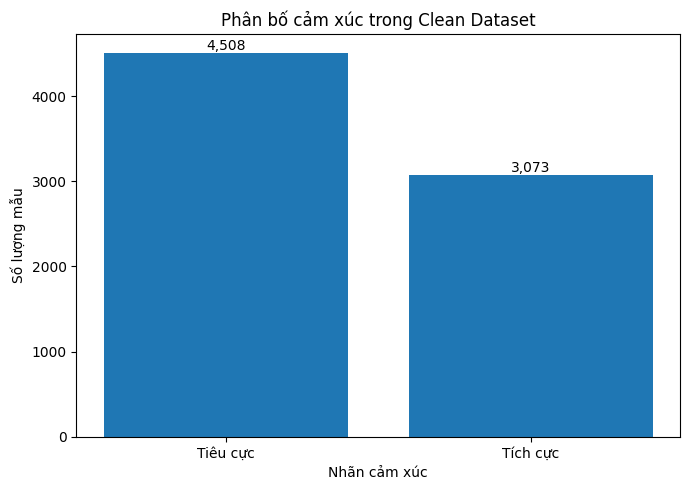

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dataset
df = pd.read_csv("clean_dataset.csv")

# Đếm số lượng từng nhãn
label_counts = df["label"].value_counts().sort_index()

# Đổi tên nhãn
labels = ["Tiêu cực", "Tích cực"]
counts = [
    label_counts.get(0, 0),
    label_counts.get(1, 0)
]

# Vẽ biểu đồ
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, counts)

plt.title("Phân bố cảm xúc trong Clean Dataset")
plt.xlabel("Nhãn cảm xúc")
plt.ylabel("Số lượng mẫu")

# Hiển thị số trên đầu cột
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("Tổng hợp biểu đồ/01_phan_bo_nhan.png", dpi=300, bbox_inches="tight")
plt.show()

# BIỂU ĐỒ TRAIN-DEV-TEST

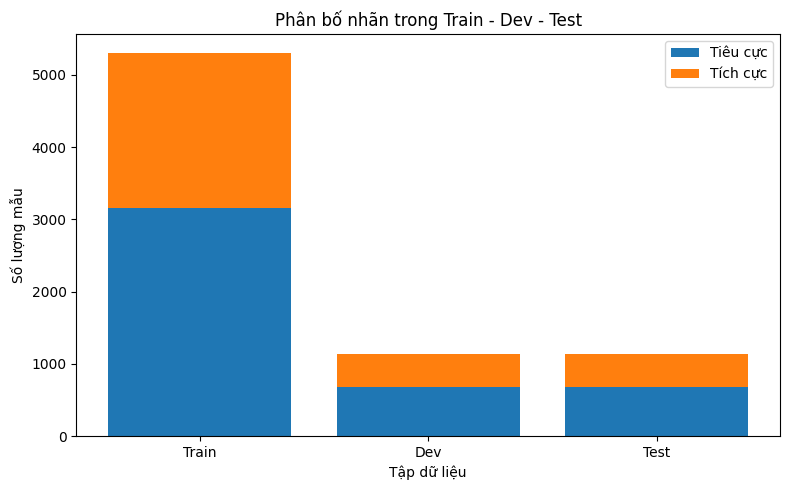

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("train_dataset.csv")
dev_df = pd.read_csv("dev_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")

datasets = {
    "Train": train_df,
    "Dev": dev_df,
    "Test": test_df
}

negative = []
positive = []

for name, data in datasets.items():
    negative.append((data["label"] == 0).sum())
    positive.append((data["label"] == 1).sum())

x = range(len(datasets))

plt.figure(figsize=(8, 5))

plt.bar(
    x,
    negative,
    label="Tiêu cực"
)

plt.bar(
    x,
    positive,
    bottom=negative,
    label="Tích cực"
)

plt.xticks(x, datasets.keys())

plt.xlabel("Tập dữ liệu")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố nhãn trong Train - Dev - Test")

plt.legend()

plt.tight_layout()
plt.savefig("Tổng hợp biểu đồ/02_pbo_train_dev_test.png", dpi=300, bbox_inches="tight")
plt.show()

# TRAIN VÀ LOSS THEO EPOCH

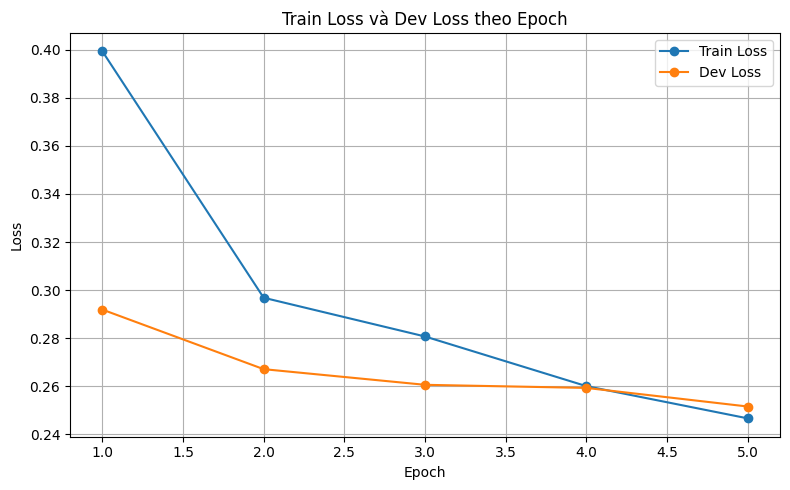

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("training_history.csv")

plt.figure(figsize=(8, 5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["epoch"],
    history["dev_loss"],
    marker="o",
    label="Dev Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss và Dev Loss theo Epoch")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Tổng hợp biểu đồ/03_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# DEV ACCURACY, PREC, RECALL

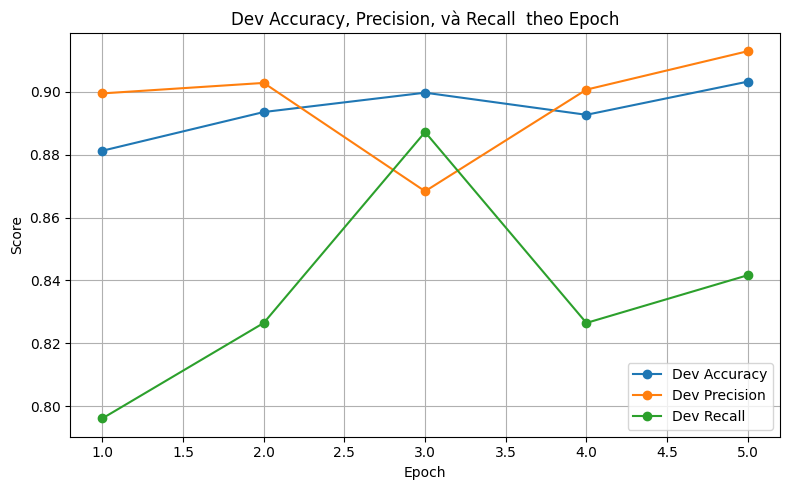

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("training_history.csv")

plt.figure(figsize=(8, 5))

plt.plot(
    history["epoch"],
    history["dev_accuracy"],
    marker="o",
    label="Dev Accuracy"
)

plt.plot(
    history["epoch"],
    history["dev_precision"],
    marker="o",
    label="Dev Precision"
)

plt.plot(
    history["epoch"],
    history["dev_recall"],
    marker="o",
    label="Dev Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Dev Accuracy, Precision, và Recall  theo Epoch")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("Tổng hợp biểu đồ/04_dev_acc_rec_pre.png", dpi=300, bbox_inches="tight")
plt.show()

# MA TRẬN NHẦM LẪN CONFUSION MATRIX

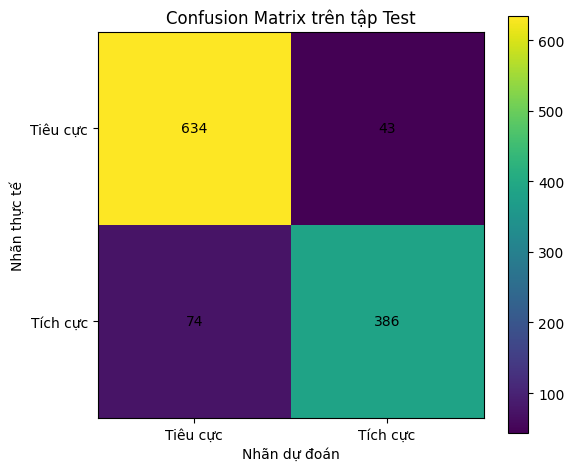

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cm = pd.read_csv(
    "test_confusion_matrix.csv",
    index_col=0
)

plt.figure(figsize=(6, 5))

plt.imshow(cm.values)

plt.title("Confusion Matrix trên tập Test")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")

plt.xticks(
    [0, 1],
    ["Tiêu cực", "Tích cực"]
)

plt.yticks(
    [0, 1],
    ["Tiêu cực", "Tích cực"]
)

# Hiển thị số lượng trên từng ô
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.savefig("Tổng hợp biểu đồ/05_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# CHỈ SỐ TRÊN TẬP TEST

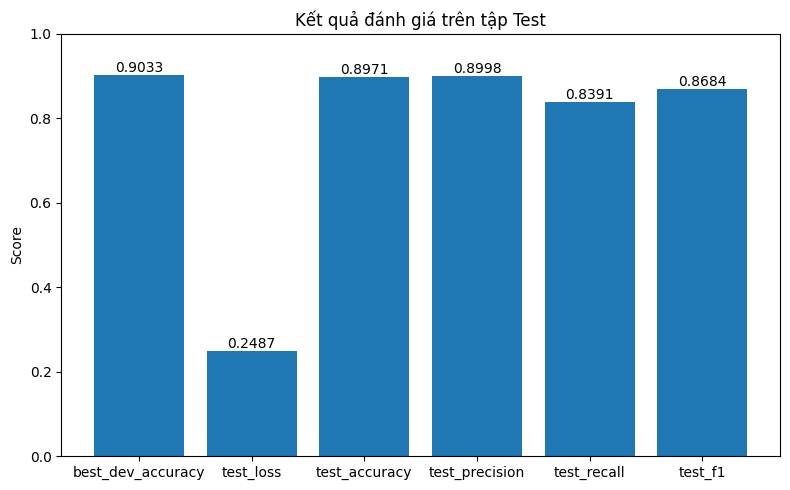

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv("test_metrics.csv")

# Nếu file có dạng metric,value
if "metric" in metrics.columns and "value" in metrics.columns:
    names = metrics["metric"]
    values = metrics["value"]
else:
    names = metrics.columns
    values = metrics.iloc[0]

plt.figure(figsize=(8, 5))

bars = plt.bar(names, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Kết quả đánh giá trên tập Test")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("Tổng hợp biểu đồ/06_test_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# app.py **old**

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from models import PhoBERT_BILSTM_Attention

st.set_page_config(page_title="HỆ THỐNG PHÂN LOẠI CẢM XÚC VĂN BẢN", layout="centered")

st.markdown("""
    <style>
    /* Hiệu ứng font chữ và màu sắc theo bản vẽ tay */
    .welcome-text {
        color: #FF4B4B;
        font_family: 'Arial';
        font-size: 24px;
        font-weight: bold;
        text-align: center;
        margin-bottom: -10px;
    }
    .main-title {
        color: #1E1E1E;
        font-family: 'Courier New', monospace;
        font-size: 42px;
        font-weight: 900;
        text-align: center;
        line-height: 1.2;
        letter-spacing: 2px;
    }
    .sub-title {
        font-size: 20px;
        font-weight: bold;
        color: #333333;
        margin-top: 30px;
    }
    /* Hiệu ứng hover đổi màu cho các nút bấm và vùng tương tác */
    div.stButton > button:first-child {
        background-color: #f0f2f6;
        color: #333;
        border-radius: 8px;
        transition: all 0.3s ease;
    }
    div.stButton > button:first-child:hover {
        background-color: #FF4B4B;
        color: white;
        transform: scale(1.02);
    }
    </style>
""", unsafe_allow_html=True)

st.markdown('<p class="welcome-text">chào mừng bạn đến với</p>', unsafe_allow_html=True)
st.markdown('<p class="main-title">PHÂN LOẠI CẢM XÚC<br>VĂN BẢN</p>', unsafe_allow_html=True)

@st.cache_resource
def load_resources():
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
    model = PhoBERT_BILSTM_Attention()
    # Nạp trọng số từ file train.py (đảm bảo file best_model.pt đã nằm cùng thư mục)
    model.load_state_dict(torch.load("best_model.pt", map_location=torch.device('cpu')))
    model.model_eval = model.eval()
    return tokenizer, model

try:
    tokenizer, model = load_resources()
except Exception as e:
    st.error("⚠️ Không tìm thấy file 'best_model.pt'. Vui lòng chạy file 'train.py' trước để huấn luyện mô hình!")
    st.stop()

st.markdown('<p class="sub-title">Vui lòng chọn 1 trong 2 lựa chọn:</p>', unsafe_allow_html=True)
selection = st.radio("", ["👉 Phân tích 1 câu trực tiếp", "👉 Phân tích qua File dữ liệu"], label_visibility="collapsed")

st.markdown("---")

#Option1: Ptich câu hỏi trực tiếp
if selection == "👉 Phân tích 1 câu trực tiếp":
    st.subheader("📝 Nhập văn bản đơn lẻ")
    user_input = st.text_input("Nhập bình luận tiếng Việt của bạn vào đây:", "Sản phẩm dùng rất tốt, giao hàng siêu nhanh!")

    if st.button("🚀 Bắt đầu phân tích cảm xúc"):
        if user_input.strip() == "":
            st.warning("Vui lòng không để trống ô nhập liệu.")
        else:
            # Tokenize câu đầu vào
            inputs = tokenizer(user_input, return_tensors="pt", max_length=64, padding='max_length', truncation=True)
            input_ids = inputs['input_ids']
            attention_mask = inputs['attention_mask']
            tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

            # Dự đoán
            with torch.no_grad():
                logits, attn_weights = model(input_ids, attention_mask)

            prediction = logits.argmax(dim=1).item()
            probs = torch.softmax(logits, dim=1)

            # Hiển thị kết quả kèm HIỆU ỨNG chúc mừng/sắc thái
            st.markdown("### 📊 Kết quả đánh giá từ AI:")
            if prediction == 1:
                st.balloons() # Hiệu ứng bóng bay chúc mừng khi gặp tin Tích cực
                st.success(f"😊 **TÍCH CỰC** (Độ tin cậy: {probs[0][1]*100:.2f}%)")
            else:
                st.snow() # Hiệu ứng tuyết rơi lạnh lùng khi gặp tin Tiêu cực
                st.error(f"🤬 **TIÊU CỰC** (Độ tin cậy: {probs[0][0]*100:.2f}%)")

            # Vẽ biểu đồ giải thích XAI (Attention Weights)
            st.markdown("### 🧠 Bản đồ giải thích quyết định (XAI - Attention Weights):")
            valid_indices = [i for i, t in enumerate(tokens) if t not in ['<s>', '</s>', '<pad>']]
            clean_tokens = [tokens[i].replace("_", " ") for i in valid_indices]
            clean_weights = (attn_weights[0, valid_indices, 0].cpu().numpy())

            fig, ax = plt.subplots(figsize=(8, len(clean_tokens) * 0.35 + 1))
            ax.barh(clean_tokens, clean_weights, color='#FF4B4B' if prediction==0 else '#2ED573')
            ax.set_xlabel('Mức độ tập trung của mô hình (Attention Weight)')
            ax.invert_yaxis()
            st.pyplot(fig)
#Option2: Phân tích qua file dữ liệu
else:
    st.subheader("📁 Đánh giá dữ liệu hàng loạt từ File")
    uploaded_file = st.file_uploader("Kéo thả hoặc chọn file dữ liệu của bạn tại đây", type=["csv", "xlsx"])

    if uploaded_file is not None:
        # Tự động nhận diện đuôi file để đọc dữ liệu
        df = pd.read_csv(uploaded_file) if uploaded_file.name.endswith('.csv') else pd.read_excel(uploaded_file)

        st.write("👀 Xem trước dữ liệu vừa tải lên:")
        st.dataframe(df.head(3))

        # Cho người dùng lựa chọn cột văn bản cần xử lý
        text_column = st.selectbox("Chọn cột chứa nội dung bình luận cần AI phân tích:", df.columns)

        if st.button("⚡ Chạy phân tích hàng loạt"):
            predictions, confidences = [], []

            # Hiển thị thanh tiến trình động (Progress Bar)
            progress_bar = st.progress(0)
            status_text = st.empty()
            total_rows = len(df)

            for idx, text in enumerate(df[text_column]):
                progress_bar.progress((idx + 1) / total_rows)
                status_text.text(f"⏳ Đang quét dữ liệu: {idx + 1}/{total_rows} dòng...")

                if pd.isna(text) or str(text).strip() == "":
                    predictions.append("Không xác định")
                    confidences.append("0%")
                    continue

                # Chạy mô hình PhoBERT dự đoán nhanh
                inputs = tokenizer(str(text), return_tensors="pt", max_length=64, padding='max_length', truncation=True)
                with torch.no_grad():
                    logits, _ = model(inputs['input_ids'], inputs['attention_mask'])

                pred = logits.argmax(dim=1).item()
                prob = torch.softmax(logits, dim=1)

                predictions.append("Tích cực" if pred == 1 else "Tiêu cực")
                confidences.append(f"{prob[0][pred]*100:.2f}%")

            # Thêm kết quả vào bảng dữ liệu
            df['AI Đự Đoán'] = predictions
            df['Độ Tin Cậy'] = confidences

            status_text.text("🎉 Đã phân tích xong toàn bộ file!")
            st.balloons() # Bắn bóng bay ăn mừng hoàn thành nhiệm vụ

            # Thống kê tổng quan bằng biểu đồ tròn
            st.markdown("### 📈 Thống kê phân phối sắc thái:")
            col1, col2 = st.columns([1, 1])
            with col1:
                st.dataframe(df[[text_column, 'AI Đự Đoán', 'Độ Tin Cậy']].head(10))
            with col2:
                fig, ax = plt.subplots(figsize=(4, 3))
                df['AI Đự Đoán'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ED573', '#FF4B4B', '#CCCCCC'], ax=ax)
                ax.set_ylabel('')
                st.pyplot(fig)

            # Nút bấm xuất và tải file kết quả về máy
            csv_output = df.to_csv(index=False, encoding="utf-8-sig").encode('utf-8-sig')
            st.download_button(
                label="📥 Tải xuống file kết quả phân tích (.CSV)",
                data=csv_output,
                file_name="ket_qua_cam_xuc_AI.csv",
                mime="text/csv"
            )


Overwriting app.py


In [ ]:
import os
print(os.path.abspath('app.py'))

/content/app.py
